In [1]:
!pip install numpy pandas scikit-learn imbalanced-learn xgboost lightgbm mlxtend matplotlib seaborn tabulate joblib pickle-mixin

In [1]:
# KC2 — Step 1: Load and inspect dataset
import os
import pandas as pd
import numpy as np

path = "/content/kc2.csv"
if not os.path.exists(path):
    from google.colab import files
    print("kc2.csv not found in /content/. Please upload kc2.csv now.")
    uploaded = files.upload()
    path = list(uploaded.keys())[0]

df3 = pd.read_csv(path)

print("Loaded file:", path)
print("Shape:", df3.shape)
print("\nColumns:\n", df3.columns.tolist())

# Detect label column
label_candidates = ['defects','defect','defective','bug','label','target','class','is_defective','Defective','DEFECT']
label_col = None
for c in df3.columns:
    if c.lower() in [x.lower() for x in label_candidates]:
        label_col = c
        break

if label_col is None:
    print("\nNo label column detected automatically.")
    print("Please provide the exact label column name (or rename the column to one of):", label_candidates)
else:
    print("\nDetected label column:", label_col)
    print("Class distribution:")
    print(df3[label_col].value_counts(dropna=False))


Loaded file: /content/kc2.csv
Shape: (522, 22)

Columns:
 ['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't', 'lOCode', 'lOComment', 'lOBlank', 'lOCodeAndComment', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount', 'problems']

No label column detected automatically.
Please provide the exact label column name (or rename the column to one of): ['defects', 'defect', 'defective', 'bug', 'label', 'target', 'class', 'is_defective', 'Defective', 'DEFECT']


In [2]:
df3.head()

,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,lOCode,lOComment,lOBlank,lOCodeAndComment,uniq_Op,uniq_Opnd,total_Op,total_Opnd,branchCount,problems
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.30,1.30,1.30,...,2,2,2,2,1.2,1.2,1.2,1.2,1.4,no
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.00,1.00,1.00,...,1,1,1,1,1.0,1.0,1.0,1.0,1.0,yes
2,415.0,59.0,50.0,51.0,1159.0,8411.31,0.01,103.53,81.24,870848.58,...,359,35,9,10,47.0,106.0,692.0,467.0,106.0,yes
3,230.0,33.0,10.0,16.0,575.0,3732.82,0.03,39.82,93.74,148644.06,...,174,15,34,5,23.0,67.0,343.0,232.0,65.0,yes
4,175.0,26.0,12.0,13.0,500.0,3123.96,0.03,29.48,105.96,92103.07,...,142,7,19,4,18.0,58.0,310.0,190.0,51.0,yes


In [3]:
# KC2 Step 2: Preprocessing and Label Encoding
from sklearn.preprocessing import LabelEncoder

# Encode the label column
df3['problems'] = df3['problems'].str.lower().map({'yes': 1, 'no': 0})
print("Unique values in label column after encoding:", df3['problems'].unique())

# Split into features and labels
X3 = df3.drop(columns=['problems'])
y3 = df3['problems']

print("\nFeature matrix shape:", X3.shape)
print("Target vector shape:", y3.shape)

# Basic statistics
print("\nClass distribution:")
print(y3.value_counts())

print("\nSummary statistics for first few columns:")
print(X3.describe().iloc[:, :5])


Unique values in label column after encoding: [0 1]

Feature matrix shape: (522, 21)
Target vector shape: (522,)

Class distribution:
problems
0    415
1    107
Name: count, dtype: int64

Summary statistics for first few columns:
               loc        v(g)       ev(g)       iv(g)            n
count   522.000000  522.000000  522.000000  522.000000   522.000000
mean     36.894828    4.893487    2.447126    3.650192    94.630843
std      77.944048   10.976772    6.665003    8.054860   233.230165
min       1.000000    1.000000    1.000000    1.000000     1.000000
25%       4.000000    1.000000    1.000000    1.000000     5.000000
50%      13.000000    2.000000    1.000000    2.000000    27.000000
75%      45.000000    5.000000    1.000000    4.000000   104.750000
max    1275.000000  180.000000  125.000000  143.000000  3982.000000


In [5]:
!pip install -U numpy==1.26.4 scikit-learn==1.4.2 --force-reinstall


  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached scikit_learn-1.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (11 kB)
  Using cached scipy-1.16.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (62 kB)
  Using cached joblib-1.5.2-py3-none-any.whl.metadata (5.6 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
Using cached scikit_learn-1.4.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.2 MB)
Using cached joblib-1.5.2-py3-none-any.whl (308 kB)
Using cached scipy-1.16.3-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (35.7 MB)
Using cached threadpoolctl-3.6.0-py3-none-any.whl (18 kB)
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.6.0
    Uninstalling threadpoolctl-3.6.0:
      Successfully u

In [4]:
# KC2 Step 3: Feature Selection + SMOTE
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import pandas as pd

# 1. Variance filter
sel = VarianceThreshold(threshold=0.0)
X3_var = sel.fit_transform(X3)
X3_var = pd.DataFrame(X3_var, columns=X3.columns[sel.get_support()])
print(f"After variance threshold: {X3_var.shape}")

# 2. Correlation filter
corr_matrix = X3_var.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]
X3_corr = X3_var.drop(columns=to_drop)
print(f"Dropping highly correlated features: {to_drop}")
print(f"After correlation filter: {X3_corr.shape}")

# 3. Mutual Information
mi = mutual_info_classif(X3_corr, y3, random_state=42)
mi_series = pd.Series(mi, index=X3_corr.columns).sort_values(ascending=False)
print("\nTop 10 features by mutual information:")
print(mi_series.head(10))

# 4. Recursive Feature Elimination (RFE)
rfe_model = RandomForestClassifier(random_state=42)
rfe = RFE(rfe_model, n_features_to_select=13)
rfe.fit(X3_corr, y3)
selected_features = X3_corr.columns[rfe.support_]
print("\nSelected features via RFE:", list(selected_features))

X3_sel = X3_corr[selected_features]
print("Final X3_sel shape:", X3_sel.shape)

# 5. SMOTE balancing
sm = SMOTE(random_state=42)
X3_res, y3_res = sm.fit_resample(X3_sel, y3)

print("\nBefore SMOTE class distribution:", np.bincount(y3))
print("After SMOTE class distribution:", np.bincount(y3_res))
print("Resampled shape:", X3_res.shape)


After variance threshold: (522, 21)
Dropping highly correlated features: ['v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'e', 'b', 't', 'lOCode', 'lOBlank', 'uniq_Op', 'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount']
After correlation filter: (522, 6)

Top 10 features by mutual information:
loc                 0.144523
i                   0.135855
d                   0.126609
l                   0.109995
lOComment           0.101891
lOCodeAndComment    0.049569
dtype: float64

Selected features via RFE: ['loc', 'l', 'd', 'i', 'lOComment', 'lOCodeAndComment']
Final X3_sel shape: (522, 6)

Before SMOTE class distribution: [415 107]
After SMOTE class distribution: [415 415]
Resampled shape: (830, 6)


In [5]:
# KC2 Step 4: Base Model Evaluation
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import make_scorer, roc_auc_score, f1_score, precision_score, recall_score
import numpy as np

def evaluate_model(model, X, y, cv=5):
    kf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=42)
    aucs, f1s, precisions, recalls = [], [], [], []
    for train_idx, test_idx in kf.split(X, y):
        Xtr, Xte = X.iloc[train_idx], X.iloc[test_idx]
        ytr, yte = y[train_idx], y[test_idx]
        model.fit(Xtr, ytr)
        preds = model.predict(Xte)
        probs = model.predict_proba(Xte)[:,1]
        aucs.append(roc_auc_score(yte, probs))
        f1s.append(f1_score(yte, preds))
        precisions.append(precision_score(yte, preds))
        recalls.append(recall_score(yte, preds))
    return {
        'auc': (np.mean(aucs), np.std(aucs)),
        'f1': (np.mean(f1s), np.std(f1s)),
        'precision': (np.mean(precisions), np.std(precisions)),
        'recall': (np.mean(recalls), np.std(recalls))
    }

models3 = {
    'LR': LogisticRegression(max_iter=1000, random_state=42),
    'SVC': SVC(kernel='rbf', probability=True, random_state=42),
    'RF': RandomForestClassifier(random_state=42),
    'ET': ExtraTreesClassifier(random_state=42),
    'XGB': XGBClassifier(eval_metric='logloss', random_state=42),
    'LGB': LGBMClassifier(random_state=42)
}

results3 = {}
for name, model in models3.items():
    results3[name] = evaluate_model(model, X3_res, y3_res)
    print(f"{name}: {results3[name]}")


LR: {'auc': (0.8446508927275367, 0.014176062732493689), 'f1': (0.7761514712510506, 0.012322715902743612), 'precision': (0.8028526071610358, 0.02287427459690749), 'recall': (0.7518072289156627, 0.018032083791681666)}
SVC: {'auc': (0.8354478153578169, 0.023731308465661235), 'f1': (0.8019850520284415, 0.017519352585400494), 'precision': (0.7902431592233794, 0.023980022837092194), 'recall': (0.8144578313253013, 0.018032083791681655)}
RF: {'auc': (0.9272753665263463, 0.02186408935728862), 'f1': (0.8593268094117936, 0.02482634277109029), 'precision': (0.8450296714285237, 0.03240852343903107), 'recall': (0.8746987951807229, 0.024808747327679515)}
ET: {'auc': (0.9364929597909711, 0.009952866503837915), 'f1': (0.8831961710867464, 0.019175787607300526), 'precision': (0.8665300027950631, 0.027385167318843832), 'recall': (0.9012048192771085, 0.02336231256586182)}
XGB: {'auc': (0.9158513572361737, 0.015064505934366739), 'f1': (0.8624097991571633, 0.015508422184586163), 'precision': (0.8723992673992

In [6]:
# KC2 Step 5: Tuning + Stacking Ensemble
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score, matthews_corrcoef, accuracy_score
import time
import numpy as np
import pandas as pd

# --- Random Forest Tuning ---
rf_params = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params, scoring='roc_auc', cv=5, n_jobs=-1
)
start = time.time()
rf_grid.fit(X3_res, y3_res)
rf_best = rf_grid.best_estimator_
rf_time = time.time() - start
print(f"Best RF params: {rf_grid.best_params_}, AUC: {rf_grid.best_score_:.4f}, time: {rf_time:.2f}s")

# --- Extra Trees Tuning ---
et_params = {
    'n_estimators': [200, 400, 600],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

et_grid = GridSearchCV(
    ExtraTreesClassifier(random_state=42),
    et_params, scoring='roc_auc', cv=5, n_jobs=-1
)
start = time.time()
et_grid.fit(X3_res, y3_res)
et_best = et_grid.best_estimator_
et_time = time.time() - start
print(f"Best ET params: {et_grid.best_params_}, AUC: {et_grid.best_score_:.4f}, time: {et_time:.2f}s")

# --- Stacking Ensemble ---
stack = StackingClassifier(
    estimators=[
        ('rf', rf_best),
        ('et', et_best),
        ('xgb', XGBClassifier(eval_metric='logloss', random_state=42)),
        ('lgb', LGBMClassifier(random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5,
    n_jobs=-1
)

# --- Cross-validation evaluation ---
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metrics = {'AUC': [], 'F1': [], 'Precision': [], 'Recall': [], 'MCC': [], 'Accuracy': []}
start = time.time()

for train_idx, test_idx in kf.split(X3_res, y3_res):
    Xtr, Xte = X3_res.iloc[train_idx], X3_res.iloc[test_idx]
    ytr, yte = y3_res[train_idx], y3_res[test_idx]
    stack.fit(Xtr, ytr)
    preds = stack.predict(Xte)
    probs = stack.predict_proba(Xte)[:, 1]
    metrics['AUC'].append(roc_auc_score(yte, probs))
    metrics['F1'].append(f1_score(yte, preds))
    metrics['Precision'].append(precision_score(yte, preds))
    metrics['Recall'].append(recall_score(yte, preds))
    metrics['MCC'].append(matthews_corrcoef(yte, preds))
    metrics['Accuracy'].append(accuracy_score(yte, preds))

end = time.time()

results_df = pd.DataFrame(metrics)
print("\nStacking Ensemble Results (mean ± std):")
for m in metrics.keys():
    print(f"{m}: {results_df[m].mean():.4f} ± {results_df[m].std():.4f}")
print(f"\nTraining time: {end - start:.2f}s")


Best RF params: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 600}, AUC: 0.9270, time: 176.16s
Best ET params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}, AUC: 0.9349, time: 94.69s

Stacking Ensemble Results (mean ± std):
AUC: 0.9388 ± 0.0151
F1: 0.8805 ± 0.0277
Precision: 0.8746 ± 0.0338
Recall: 0.8867 ± 0.0250
MCC: 0.7593 ± 0.0569
Accuracy: 0.8795 ± 0.0286

Training time: 58.62s


Loaded KC1 shape: (2109, 22)
=== Cross-dataset Evaluation: KC2-trained model -> KC1 test ===
AUC: 0.7420
PR-AUC: 0.3013
Accuracy: 0.8042
Precision: 0.3746
Recall: 0.3988
F1-score: 0.3863
MCC: 0.2701
Log Loss: 0.4445

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.88      0.88      1783
           1       0.37      0.40      0.39       326

    accuracy                           0.80      2109
   macro avg       0.63      0.64      0.63      2109
weighted avg       0.81      0.80      0.81      2109



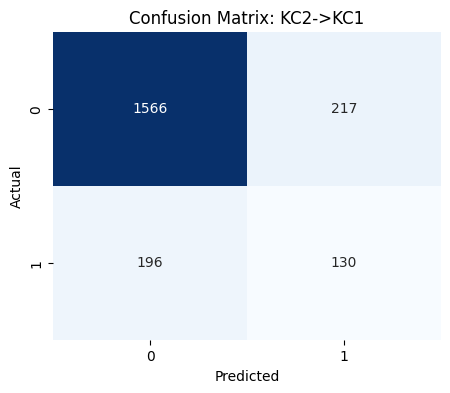

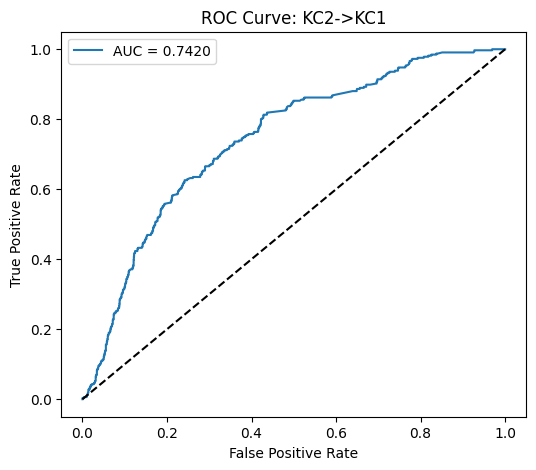

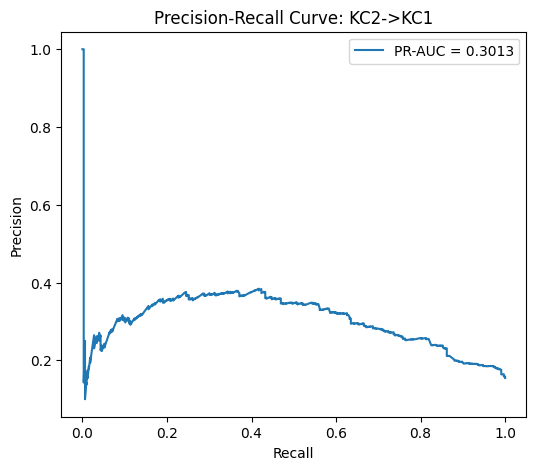

,Metric,Value
0,AUC,0.741952
1,PR-AUC,0.301316
2,Accuracy,0.804173
3,Precision,0.374640
4,Recall,0.398773
5,F1-score,0.386330
6,MCC,0.270149
7,Log Loss,0.444543


In [14]:
# === Cross-dataset test: KC2-trained stack --> evaluate on KC1 (no retraining) ===
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_curve, auc, precision_recall_curve, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, log_loss, classification_report
)
from sklearn.preprocessing import LabelEncoder

# 1) Load KC1
kc1_path = "/content/kc1.csv"   # change path if different
df_kc1 = pd.read_csv(kc1_path)
print("Loaded KC1 shape:", df_kc1.shape)

# 2) Prepare KC1 label column
# If label column is named 'defects' (True/False) convert to 0/1; adjust if different
if 'defects' in df_kc1.columns:
    y_kc1 = df_kc1['defects'].map({False:0, True:1}).astype(int)
else:
    # try to find a plausible label name
    possible = [c for c in df_kc1.columns if c.lower() in ['defects','defect','problems','bug','label','target','class']]
    if possible:
        y_kc1 = df_kc1[possible[0]].astype(str).str.lower().map({'yes':1,'true':1,'1':1,'y':1,'no':0,'false':0,'0':0,'n':0}).astype(int)
    else:
        raise ValueError("No label column found in kc1.csv. Rename the label column to 'defects' or similar.")

# 3) Select features to match KC2 model (the features used for KC2 stacking)
kc2_features = ['loc', 'l', 'd', 'i', 'lOComment', 'lOCodeAndComment']

# 4) Build KC1 feature matrix with alignment (fill missing features with zeros)
X_kc1 = pd.DataFrame(index=df_kc1.index)
for f in kc2_features:
    if f in df_kc1.columns:
        X_kc1[f] = df_kc1[f]
    else:
        # fill absent feature with zeros (safe fallback)
        X_kc1[f] = 0.0
        print(f"Warning: feature '{f}' not found in KC1 — filled with 0s for alignment.")

# 5) Ensure column order matches
X_kc1 = X_kc1[kc2_features]

# 6) If any non-numeric columns, attempt to convert
X_kc1 = X_kc1.apply(pd.to_numeric, errors='coerce').fillna(0.0)

# 7) Predict using your already-trained KC2 stacking model (variable name: stack)
y_pred_kc1 = stack.predict(X_kc1)
y_prob_kc1 = stack.predict_proba(X_kc1)[:,1]

# 8) Compute metrics
fpr, tpr, _ = roc_curve(y_kc1, y_prob_kc1)
prec, rec, _ = precision_recall_curve(y_kc1, y_prob_kc1)
roc_auc = auc(fpr, tpr)
pr_auc = auc(rec, prec)
ll = log_loss(y_kc1, y_prob_kc1)
cm = confusion_matrix(y_kc1, y_pred_kc1)
acc = accuracy_score(y_kc1, y_pred_kc1)
prec_val = precision_score(y_kc1, y_pred_kc1, zero_division=0)
rec_val = recall_score(y_kc1, y_pred_kc1, zero_division=0)
f1_val = f1_score(y_kc1, y_pred_kc1, zero_division=0)
mcc_val = matthews_corrcoef(y_kc1, y_pred_kc1)

# 9) Print summary
print("=== Cross-dataset Evaluation: KC2-trained model -> KC1 test ===")
print(f"AUC: {roc_auc:.4f}")
print(f"PR-AUC: {pr_auc:.4f}")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec_val:.4f}")
print(f"Recall: {rec_val:.4f}")
print(f"F1-score: {f1_val:.4f}")
print(f"MCC: {mcc_val:.4f}")
print(f"Log Loss: {ll:.4f}")
print("\nClassification Report:\n", classification_report(y_kc1, y_pred_kc1, zero_division=0))

# 10) Plots (Confusion matrix, ROC, PR)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Confusion Matrix: KC2->KC1")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curve: KC2->KC1")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"PR-AUC = {pr_auc:.4f}")
plt.title("Precision-Recall Curve: KC2->KC1")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.show()

# 11) Save results table for paper
cross_results = pd.DataFrame({
    'Metric': ['AUC','PR-AUC','Accuracy','Precision','Recall','F1-score','MCC','Log Loss'],
    'Value': [roc_auc, pr_auc, acc, prec_val, rec_val, f1_val, mcc_val, ll]
})
display(cross_results)


In [18]:
# Recreate KC2 test predictions from your trained stacking model
from sklearn.model_selection import train_test_split

# Assuming X3_res, y3_res were your KC2 dataset after SMOTE
X_train, X_test, y_train, y_test = train_test_split(X3_res, y3_res, test_size=0.2, random_state=42, stratify=y3_res)

# Predict on KC2 test set
y_pred = stack.predict(X_test)
y_prob = stack.predict_proba(X_test)[:, 1]


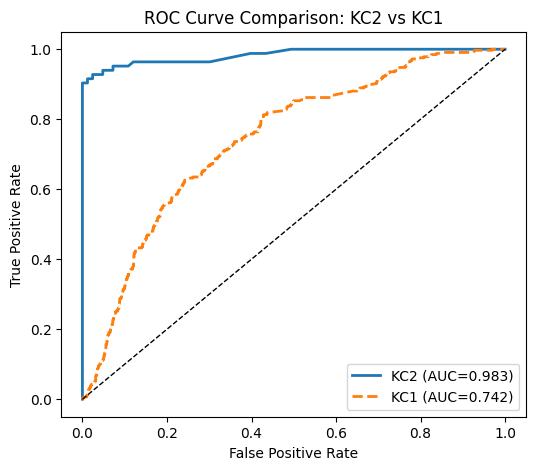

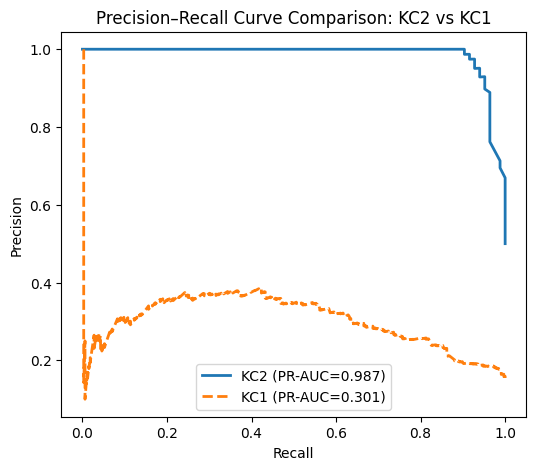

In [19]:
# === Compare KC2 (within-project) vs KC1 (cross-project) ===
from sklearn.metrics import roc_curve, auc, precision_recall_curve

# Compute curves for KC2 test if not already saved
fpr_kc2, tpr_kc2, _ = roc_curve(y_test, y_prob)
prec_kc2, rec_kc2, _ = precision_recall_curve(y_test, y_prob)
auc_kc2 = auc(fpr_kc2, tpr_kc2)
pr_auc_kc2 = auc(rec_kc2, prec_kc2)

# ROC comparison
plt.figure(figsize=(6,5))
plt.plot(fpr_kc2, tpr_kc2, label=f"KC2 (AUC={auc_kc2:.3f})", lw=2)
plt.plot(fpr, tpr, label=f"KC1 (AUC={roc_auc:.3f})", lw=2, linestyle='--')
plt.plot([0,1],[0,1],'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: KC2 vs KC1")
plt.legend()
plt.show()

# Precision–Recall comparison
plt.figure(figsize=(6,5))
plt.plot(rec_kc2, prec_kc2, label=f"KC2 (PR-AUC={pr_auc_kc2:.3f})", lw=2)
plt.plot(rec, prec, label=f"KC1 (PR-AUC={pr_auc:.3f})", lw=2, linestyle='--')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve Comparison: KC2 vs KC1")
plt.legend()
plt.show()
